Task-1 Customer Support Ticket Dataset

In [1]:
import pandas as pd
import nltk
import re
import string
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
nltk.download('punkt', force=True)
nltk.download('stopwords', force=True)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
df = pd.read_csv("/content/customer_support_tickets.csv")

In [4]:
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower().translate(str.maketrans('', '', string.punctuation))
    tokens = re.findall(r'\b\w+\b', text)
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

In [5]:
df['cleaned_description'] = df['Ticket Description'].apply(preprocess)

In [6]:
all_words = ' '.join(df['cleaned_description']).split()
word_freq = Counter(all_words)
top_15 = word_freq.most_common(15)

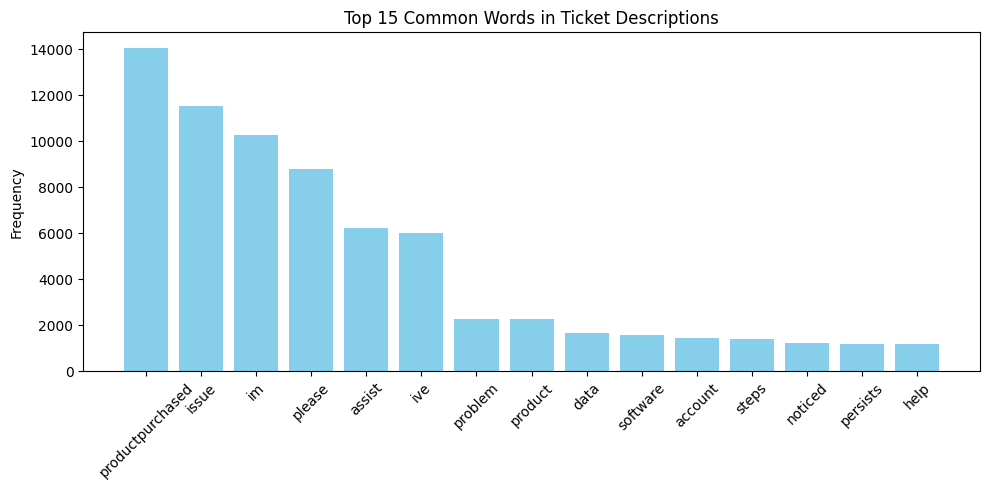

In [7]:
words, counts = zip(*top_15)
plt.figure(figsize=(10, 5))
plt.bar(words, counts, color='skyblue')
plt.title('Top 15 Common Words in Ticket Descriptions')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
top_keywords = [word for word, _ in top_15]

def categorize_issue(text):
    for keyword in top_keywords:
        if keyword in text:
            return keyword
    return 'other'

df['issue_category'] = df['cleaned_description'].apply(categorize_issue)

In [9]:
df['First Response Time'] = pd.to_numeric(df['First Response Time'], errors='coerce')
df['Time to Resolution'] = pd.to_numeric(df['Time to Resolution'], errors='coerce')
df['Customer Satisfaction Rating'] = pd.to_numeric(df['Customer Satisfaction Rating'], errors='coerce')

In [10]:
time_stats = df.groupby('issue_category')[['First Response Time', 'Time to Resolution']].mean()

In [11]:
satisfaction_stats = df.groupby('issue_category')['Customer Satisfaction Rating'].mean()

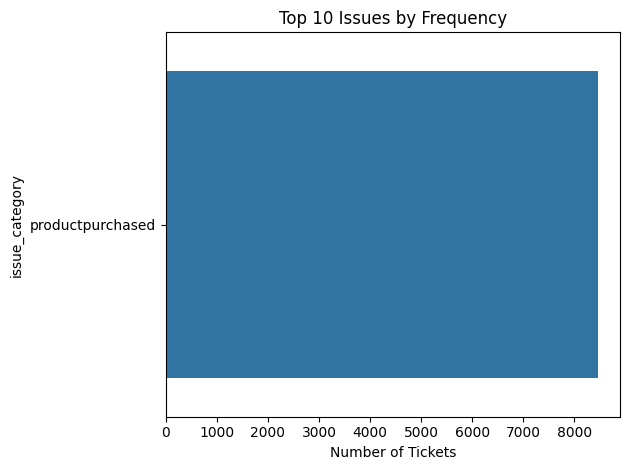

In [12]:
issue_counts = df['issue_category'].value_counts().head(10)
sns.barplot(x=issue_counts.values, y=issue_counts.index)
plt.title('Top 10 Issues by Frequency')
plt.xlabel('Number of Tickets')
plt.tight_layout()
plt.show()

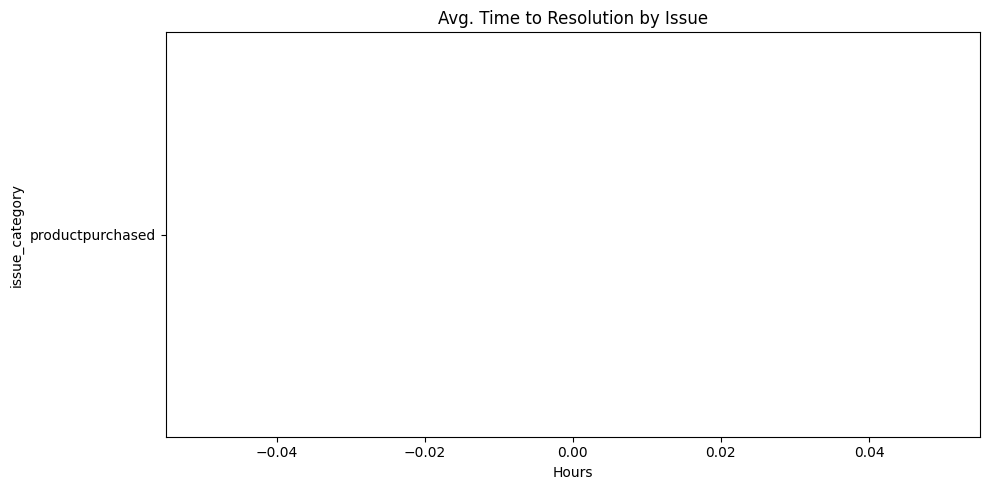

In [13]:
time_stats['Time to Resolution'].plot(kind='barh', title='Avg. Time to Resolution by Issue', figsize=(10, 5))
plt.xlabel('Hours')
plt.tight_layout()
plt.show()

In [14]:
longest_resolution = time_stats.sort_values(by='Time to Resolution', ascending=False).head(5)
lowest_satisfaction = satisfaction_stats.sort_values().head(5)
merged_stats = time_stats.join(satisfaction_stats, how='inner')
pain_points = merged_stats.sort_values(by=['Time to Resolution', 'Customer Satisfaction Rating'], ascending=[False, True]).head(5)

In [15]:
print("🔹 Top 5 Issues with Longest Resolution Times:")
print(longest_resolution)

print("\n🔹 Top 5 Issues with Lowest Customer Satisfaction:")
print(lowest_satisfaction)

print("\n🔹 Pain Points (Slow & Low Satisfaction):")
print(pain_points)

🔹 Top 5 Issues with Longest Resolution Times:
                  First Response Time  Time to Resolution
issue_category                                           
productpurchased                  NaN                 NaN

🔹 Top 5 Issues with Lowest Customer Satisfaction:
issue_category
productpurchased    2.991333
Name: Customer Satisfaction Rating, dtype: float64

🔹 Pain Points (Slow & Low Satisfaction):
                  First Response Time  Time to Resolution  \
issue_category                                              
productpurchased                  NaN                 NaN   

                  Customer Satisfaction Rating  
issue_category                                  
productpurchased                      2.991333  


In [16]:
print("\n📋 Summary Report:")
print("Most common support issues have been categorized and analyzed.")
print(f"- Issue categories such as {', '.join(longest_resolution.index[:3])} have the longest resolution times.")
print(f"- Categories like {', '.join(lowest_satisfaction.index[:3])} receive the lowest customer satisfaction scores.")
print("Recommendations:")

for issue in pain_points.index:
    print(f"- Consider creating automated responses or guided workflows for **'{issue}'** issues to reduce resolution time and improve satisfaction.")


📋 Summary Report:
Most common support issues have been categorized and analyzed.
- Issue categories such as productpurchased have the longest resolution times.
- Categories like productpurchased receive the lowest customer satisfaction scores.
Recommendations:
- Consider creating automated responses or guided workflows for **'productpurchased'** issues to reduce resolution time and improve satisfaction.
